# Temporal Cycle-Consistency Learning
## Self-supervised video representations with TCN $\rightarrow$ TCC using `aegean-ai/tcc`

This notebook is designed to read like a **tutorial** and a **course assignment** at the same time.

It focuses on one question:

> Can a self-supervised video representation learn the **latent phase** of a task purely from temporal structure, without robot control, action labels, or transcription?

The answer developed across the two Google Research papers is:

1. **TCN** learns by enforcing *time-based contrastive alignment* under strong synchronization assumptions.
2. **TCC** generalizes this idea by enforcing *temporal cycle-consistency*, which is more robust to variations in execution speed and alignment.

In this notebook you will:

- study the conceptual evolution from **TCN** to **TCC**
- train the **PyTorch rewrite** in `aegean-ai/tcc`
- extract frame embeddings
- visualize trajectories with **PCA**, **t-SNE**, and **UMAP**
- segment action sequences using representation geometry

## Papers

- Sermanet et al., **Time-Contrastive Networks**, 2018  
  https://arxiv.org/abs/1704.06888

- Dwibedi et al., **Temporal Cycle-Consistency Learning**, 2019  
  https://arxiv.org/abs/1904.07846

## Repository used in this notebook

- `https://github.com/aegean-ai/tcc`  
  This notebook assumes the **`main` branch** and the current PyTorch package layout under `src/tcc/`.

## What you should learn

By the end, you should be able to explain why TCN and TCC are related but not identical:

- TCN: **metric alignment with synchronized positives**
- TCC: **structural temporal alignment via cycles**

A useful mental model is:

- TCN says: *"frames at the same time index should be close."*
- TCC says: *"if I map from one sequence to another and back, I should return to the same temporal phase."*

## 1. Theory recap: from TCN to TCC

### 1.1 TCN: contrastive temporal alignment

TCN learns an embedding
$$
z_t = f_\theta(I_t)
$$
so that synchronized frames from different views become neighbors in feature space.

A canonical triplet-style loss is:
$$
\mathcal{L}_{\mathrm{TCN}}
=
\max\left(
0,\;
\|f(I_t^a)-f(I_t^b)\|_2^2
-
\|f(I_t^a)-f(I_{t'}^b)\|_2^2
+
\alpha
\right).
$$

Interpretation:

- **anchor:** frame $I_t^a$
- **positive:** synchronized frame $I_t^b$
- **negative:** mismatched-time frame $I_{t'}^b$

This already encodes an important idea: **time is supervision**.

But TCN assumes that corresponding frames are available at matching time indices, which is a strong assumption.

### 1.2 Why TCN is not enough

Suppose two people perform the same pouring task:

- one moves slowly
- one moves quickly
- one pauses before tilting
- one starts tilting earlier

Then the frame with semantic phase "tilt begins" is **not** guaranteed to occur at the same time index in both videos.

So absolute time matching becomes fragile.

### 1.3 TCC: align temporal structure, not raw clock time

TCC keeps the idea that embeddings should reflect task progression, but replaces hard synchronized matching with **cycle consistency**.

**Conceptual intuition.** Given frame $i$ in sequence $A$, map it to the most corresponding frame in sequence $B$:
$$
j = \arg\min_k \|f(I_i^A)-f(I_k^B)\|.
$$

Then map back from sequence $B$ to sequence $A$:
$$
i' = \arg\min_l \|f(I_j^B)-f(I_l^A)\|.
$$

TCC encourages $i' \approx i$.

**Differentiable training loss.** The hard `argmin` above is not differentiable, so the actual TCC loss replaces it with a **soft nearest-neighbor** formulation. For frame $i$ in sequence $A$, define a soft correspondence distribution over frames in sequence $B$:

$$
\beta_k^{(i)} = \frac{\exp(-\|f(I_i^A) - f(I_k^B)\|^2 / \tau)}{\sum_{k'} \exp(-\|f(I_i^A) - f(I_{k'}^B)\|^2 / \tau)}
$$

where $\tau$ is a temperature parameter. The cycle-back distribution is computed analogously, and the loss is the cross-entropy between the back-mapped distribution and a target concentrated at the original index $i$. This makes the entire cycle differentiable and trainable with standard gradient descent.

Conceptually:

- TCN aligns **absolute timestamps**
- TCC aligns **latent phase structure**

This is why TCC is more appropriate when demonstrations are semantically similar but **temporally warped**.

### 1.4 What the embedding should look like on pouring

If TCC works, then the learned trajectory in embedding space should behave like a latent phase variable:

- early reach frames cluster near other early reach frames
- grasp transitions appear near one another
- tilt and pour form coherent regions
- embeddings from different videos should trace similar temporal paths

That is the premise you will test below.

## 2. How this notebook and the `aegean-ai/tcc` repo work together

This notebook is **not** a standalone script. It is a guided analysis layer that drives the `aegean-ai/tcc` PyTorch package. The repo provides the training loop, model definitions, dataset utilities, and evaluation code. The notebook provides the experimental protocol: configuring runs, extracting embeddings, and visualizing results.

### Two supported environments

| | **Dev container (recommended)** | **Google Colab** |
|---|---|---|
| **GPU** | Local NVIDIA GPU via Docker | Colab T4/A100 runtime |
| **Package manager** | `uv` (pre-installed in container) | `pip` (Colab default) |
| **Setup effort** | `make start` — one command | Clone + pip install in notebook cells |
| **Persistence** | Full local disk | Session-scoped (data lost on disconnect) |
| **Best for** | Full sweep, large runs | Quick experiments, no local GPU |

Choose **one** environment and follow the corresponding setup path in Section 3.

### Workflow overview

```
┌──────────────────────────────────────────────────────────────────┐
│  This notebook (analysis layer)                                  │
│                                                                  │
│  1. Set up environment (dev container OR Colab)                  │
│  2. Prepare the pouring dataset                                  │
│  3. Configure training via tcc.config.get_default_config()       │
│  4. Launch training via tcc.train.train(cfg)                     │
│  5. Load checkpoints via tcc.train.load_checkpoint()             │
│  6. Extract embeddings via tcc.evaluate.get_embeddings_dataset() │
│  7. Visualize and segment (PCA, UMAP, KMeans — notebook code)   │
└──────────────────────────────────────────────────────────────────┘
         │                        ▲
         │  function calls        │  returns tensors,
         ▼                        │  checkpoints, configs
┌──────────────────────────────────────────────────────────────────┐
│  aegean-ai/tcc  (installed as editable package)                  │
│                                                                  │
│  src/tcc/                                                        │
│  ├── config.py          TCCConfig dataclass + get_default_config │
│  ├── train.py           Training loop, checkpoint save/load      │
│  ├── evaluate.py        Embedding extraction, eval metrics       │
│  ├── datasets.py        DataConfig, create_dataset()             │
│  ├── models.py          ResNet backbone + embedding head         │
│  ├── alignment.py       TCC alignment algorithm                  │
│  ├── losses.py          Cycle-consistency loss                   │
│  └── algos/             Algorithm registry (tcc, tcn, sal, …)    │
│                                                                  │
│  configs/                                                        │
│  └── default.yaml       Default hyperparameters                  │
│                                                                  │
│  scripts/                                                        │
│  └── download_pouring_data.sh                                    │
│                                                                  │
│  src/tcc/dataset_preparation/                                    │
│  ├── videos_to_dataset.py    Raw videos → image folders          │
│  ├── images_to_dataset.py    Images → dataset structure          │
│  └── visualize_dataset.py    Inspect prepared data               │
└──────────────────────────────────────────────────────────────────┘
```

### What you modify vs. what you use as-is

| Layer | You modify | You use as-is |
|-------|-----------|---------------|
| **Notebook** | Embedding dimension, iteration count, analysis parameters ($k$, projection method) | Visualization and segmentation code |
| **Repo config** | `model.conv_embedder.embedding_size`, `train.max_iters`, `logdir` | Everything else in `configs/default.yaml` |
| **Repo code** | Nothing — treat as a library | `train.py`, `evaluate.py`, `datasets.py`, `models.py` |

## 3. Environment setup

Choose **one** of the two paths below. Both result in a working `import tcc` with GPU access.

---

### Path A: Dev container (recommended for full assignment)

The repo ships a complete Docker-based development environment with GPU support, `uv`, and VS Code integration.

**Prerequisites:** Docker with NVIDIA Container Toolkit, VS Code with Dev Containers extension.

**Steps:**

1. Clone the repo locally:
   ```bash
   git clone https://github.com/aegean-ai/tcc && cd tcc
   ```
2. Copy the environment file:
   ```bash
   cp .env.example .env
   # Edit .env to add WANDB_API_KEY and/or HF_TOKEN if needed
   ```
3. Open in VS Code → "Reopen in Container" (or run `docker compose up -d` manually).
4. Inside the container, run:
   ```bash
   make start
   ```
   This creates a `.venv` with `uv`, installs the package in editable mode, and registers a Jupyter kernel.
5. Open this notebook in VS Code or JupyterLab (port 8888) and select the **"Python 3 (tcc)"** kernel.

**Key details:**
- Base image: `pytorch/pytorch:2.7.1-cuda12.8-cudnn9-runtime`
- Package manager: `uv` (not pip) — the Makefile handles all `uv` calls
- Python: whatever 3.11+ is in the container (typically from conda)
- Workspace: `/workspaces/tcc`
- TensorBoard: port 6006

**Installing extra notebook dependencies** (matplotlib, umap-learn, etc.):
```bash
make install-notebooks
```

---

### Path B: Google Colab (quick start, no local GPU needed)

Use this path if you do not have a local GPU or want a fast start. Colab sessions are ephemeral — save checkpoints to Google Drive to avoid losing training results.

**Steps:**

1. In a Colab notebook, enable GPU: **Runtime → Change runtime type → T4 GPU**.
2. Run the clone and install cells below (Section 3.1–3.2).
3. Colab uses `pip` — the `%pip install` commands handle everything.

**Limitations:**
- Session timeout erases all local files. Mount Google Drive for persistence:
  ```python
  from google.colab import drive
  drive.mount('/content/drive')
  # Point EXPERIMENT_ROOT and DATA_ROOT to /content/drive/MyDrive/tcc/
  ```
- Colab's default Python may differ from 3.11 — the package should still install but is only tested on 3.11–3.12.

---

### Python version requirement

The repo requires **Python ≥3.11, <3.13** (`pyproject.toml`). The dev container satisfies this automatically. On Colab, check with `!python --version`.

In [1]:
import sys, platform, os, pathlib

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Working directory:", os.getcwd())

Python: 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:48:23) [GCC 13.3.0]
Platform: Linux-6.17.0-14-generic-x86_64-with-glibc2.35
Working directory: /workspaces/tcc/notebooks/self-supervised


### 3.1 Clone the repository (Colab / Path B only)

If you are using the **dev container** (Path A), skip this — the repo is already your workspace at `/workspaces/tcc`.

In [2]:
# import subprocess, pathlib

# REPO_URL = "https://github.com/aegean-ai/tcc"
# REPO_DIR = pathlib.Path("tcc")

# if not REPO_DIR.exists():
#     subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=False)
# else:
#     print("Repository already exists:", REPO_DIR)

# print("Repo dir exists:", REPO_DIR.exists())

### 3.2 Install the package (Colab / Path B only)

If you are using the **dev container** (Path A), skip this — `make start` already installed the package. Run `make install-notebooks` if you need matplotlib/umap-learn.

In [3]:
# Colab / Path B only — uncomment and run these lines:
# %pip install -e ./tcc
# %pip install matplotlib scikit-learn umap-learn tqdm pyyaml

# Dev container / Path A — these are already installed.
# If you need notebook extras, run in a terminal: make install-notebooks

# import importlib
# try:
#     importlib.import_module("tcc")
#     print("tcc package is available.")
# except ModuleNotFoundError:
#     print("tcc not found. Follow the install instructions for your environment (Path A or B).")

### 3.3 Quick repository inspection

Verify the repo structure. In the dev container the repo root is `/workspaces/tcc`; on Colab it is the cloned `tcc/` directory.

In [4]:
import os

# Detect environment: dev container vs Colab
REPO_ROOT = pathlib.Path("/workspaces/tcc") if pathlib.Path("/workspaces/tcc/src/tcc").exists() else REPO_DIR

def walk_top(path, max_depth=2):
    base = os.path.abspath(path)
    label = os.path.basename(base)
    for root, dirs, files in os.walk(base):
        depth = root[len(base):].count(os.sep)
        if depth <= max_depth:
            print(root.replace(base, label))
            for f in files[:10]:
                print("   ", f)

walk_top(str(REPO_ROOT), max_depth=2)

tcc
    1904.07846v1.pdf
    CLAUDE.md
    pyproject.toml
    .gitignore
    Makefile
    .env
    .~lock.MidTerm_writeup.odt#
    MidTerm_writeup.odt
    README.md
    uv.lock
tcc/.venv
    .gitignore
    .lock
    pyvenv.cfg
    CACHEDIR.TAG
tcc/.venv/etc
tcc/.venv/lib
tcc/.venv/share
tcc/.venv/bin
    activate_this.py
    jupyter-notebook
    ipython
    jlpm
    typer
    python3
    activate
    pygmentize
    deactivate.bat
    jupyter-console
tcc/scripts
    execute_notebook.py
    download_pouring_data.sh
tcc/docker
    Dockerfile.torch.dev.gpu
tcc/.beads
    dolt-monitor.pid
    config.yaml
    interactions.jsonl
    .gitignore
    dolt-server.port
    metadata.json
    README.md
    dolt-server.activity
tcc/.beads/hooks
    post-checkout
    post-merge
    pre-push
    prepare-commit-msg
    pre-commit
tcc/.beads/backup
    labels.jsonl
    config.jsonl
    backup_state.json
    dependencies.jsonl
    issues.jsonl
    comments.jsonl
    events.jsonl
tcc/docs
    architecture.

## 4. Data: the pouring dataset

The multiview pouring dataset is hosted on HuggingFace at [`sermanet/multiview-pouring`](https://huggingface.co/datasets/sermanet/multiview-pouring). It contains TFRecord files with multi-view video sequences of pouring tasks.

### Download from HuggingFace

Use `huggingface_hub` to download the dataset files. The code cell below clones the dataset repository into `data/pouring/`. This is the recommended approach — it downloads all TFRecord files and the recombination script needed for one split file.

### Expected directory layout

After download and conversion, the dataset root must have this structure:

```
data/pouring_processed/pouring/
├── train/
│   ├── video_001/
│   │   ├── frame_0000.png
│   │   ├── frame_0001.png
│   │   └── ...
│   ├── video_002/
│   │   └── ...
│   └── ...
└── val/
    ├── video_050/
    │   └── ...
    └── ...
```

Each video is a directory of sequentially numbered frames. The PyTorch `create_dataset` function expects this layout — it discovers videos by listing subdirectories under `train/` or `val/`, then loads frames in filename-sorted order.

In [5]:
DATA_ROOT = pathlib.Path("data")
RAW_POURING_ROOT = DATA_ROOT / "pouring"
PROCESSED_POURING_ROOT = DATA_ROOT / "pouring_processed"

RAW_POURING_ROOT.mkdir(parents=True, exist_ok=True)
PROCESSED_POURING_ROOT.mkdir(parents=True, exist_ok=True)

print("Raw data dir:", RAW_POURING_ROOT.resolve())
print("Processed data dir:", PROCESSED_POURING_ROOT.resolve())

Raw data dir: /workspaces/tcc/notebooks/self-supervised/data/pouring
Processed data dir: /workspaces/tcc/notebooks/self-supervised/data/pouring_processed


### 4.1 Download from HuggingFace

The dataset is hosted at [`sermanet/multiview-pouring`](https://huggingface.co/datasets/sermanet/multiview-pouring) and contains TFRecord files organized into `train/`, `val/`, and `test/` splits.

Use `huggingface_hub.snapshot_download` to download the full dataset. This downloads all files (TFRecords, recombination scripts, README) into a local cache and returns the path. We then symlink or copy into our expected `data/pouring/` directory.

> **Note:** One test file (`whiteorange_to_clear1_real`) was split into two parts due to upload size limits. After downloading, run the provided shell script to recombine it. This only affects the test split — training and validation are ready to use immediately.

In [6]:
# from huggingface_hub import snapshot_download

# # Download the full dataset from HuggingFace (progress bars suppressed for clean output)
# hf_cache_path = snapshot_download(
#     repo_id="sermanet/multiview-pouring",
#     repo_type="dataset",
#     local_dir=str(RAW_POURING_ROOT),
# )

# print("Dataset downloaded to:", hf_cache_path)

# # List what was downloaded
# for split_dir in sorted(RAW_POURING_ROOT.iterdir()):
#     if split_dir.is_dir() and not split_dir.name.startswith("."):
#         tfrecords = list(split_dir.glob("*.tfrecord*"))
#         print(f"  {split_dir.name}/: {len(tfrecords)} TFRecord file(s)")

In [7]:
# Step 1: Download is handled above via huggingface_hub (cell 4.1)

# Step 2 (optional): Recombine the split test file
# Only needed if you plan to use the test split
# !bash {RAW_POURING_ROOT}/tfrecords/test/whiteorange_to_clear1_real_combining.sh

# Step 3: Convert TFRecords to image-folder layout
# In the dev container terminal:
  # python -m tcc.dataset_preparation.videos_to_dataset \
  #     --input-dir /workspaces/tcc/notebooks/self-supervised/data/pouring/videos/val \
  #     --file-pattern "*.mov" \
  #     --output-dir /workspaces/tcc/notebooks/self-supervised/data/pouring_processed/val \
  #     --name pouring --fps 15 --width 224 --height 224
#
# On Colab, prefix with ! instead:
#   !python -m tcc.dataset_preparation.videos_to_dataset ...

print("After downloading from HuggingFace, convert the TFRecords to image folders.")

After downloading from HuggingFace, convert the TFRecords to image folders.


### 4.2 Expected semantic phases

We will reason about pouring in terms of latent phases such as:

1. reach
2. grasp
3. lift / position
4. tilt
5. pour
6. retract / return

You do **not** need action labels for TCC training.  
These phase names are used only for qualitative interpretation of the learned representation.

## 5. Configuration and training

The current `aegean-ai/tcc` package provides:

- a typed configuration object
- an `alignment` algorithm corresponding to TCC
- a PyTorch training loop

The default configuration is useful to inspect first, because it tells us:

- training algorithm
- dataset name
- image size
- batch size
- embedding size
- checkpoint/logging schedule

In [8]:
from pprint import pprint

try:
    from tcc.config import get_default_config
    cfg = get_default_config()
    print(cfg)
except Exception as e:
    print("Could not import tcc yet:", repr(e))
    cfg = None

TCCConfig(logdir='/tmp/alignment_logs/', datasets=['pouring'], path_to_tfrecords='/tmp/%s_tfrecords/', training_algo='alignment', train=TrainConfig(max_iters=150000, batch_size=2, num_frames=20, visualize_interval=200), eval=EvalConfig(batch_size=2, num_frames=20, val_iters=20, tasks=['algo_loss', 'classification', 'kendalls_tau', 'event_completion', 'few_shot_classification'], frames_per_batch=25, kendalls_tau_stride=5, kendalls_tau_distance='sqeuclidean', classification_fractions=[0.1, 0.5, 1.0], few_shot_num_labeled=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], few_shot_num_episodes=50), model=ModelConfig(embedder_type='conv', base_model=BaseModelConfig(network='resnet50', layer='conv4_block3_out', train_base='only_bn'), conv_embedder=ConvEmbedderConfig(embedding_size=128, num_context_steps=2, conv_layers=[(256, 3, True), (256, 3, True)], fc_layers=[(256, True), (256, True)], capacity_scalar=2, flatten_method='max_pool', base_dropout_rate=0.0, base_dropout_spatial=False, fc_dropout_rate=0.1, dro

### 5.1 Utility: robust config editing

Research repositories evolve. Rather than assuming one exact config layout, we use helper functions that can set values safely if the corresponding fields exist.

This makes the notebook more resilient to small refactors of the dataclass hierarchy.

In [9]:
def set_if_exists(obj, path, value):
    parts = path.split(".")
    cur = obj
    for p in parts[:-1]:
        if not hasattr(cur, p):
            return False
        cur = getattr(cur, p)
    if hasattr(cur, parts[-1]):
        setattr(cur, parts[-1], value)
        return True
    return False

def get_if_exists(obj, path, default=None):
    parts = path.split(".")
    cur = obj
    for p in parts:
        if not hasattr(cur, p):
            return default
        cur = getattr(cur, p)
    return cur

def summarize_config(cfg):
    keys = [
        "training_algo",
        "datasets",
        "path_to_tfrecords",
        "logdir",
        "train.batch_size",
        "train.max_iters",
        "train.num_frames",
        "eval.batch_size",
        "model.embedder_type",
        "model.conv_embedder.embedding_size",
        "model.base_model.train_base",
        "optimizer.type",
        "optimizer.lr.initial_lr",
        "data.image_size",
        "data.frame_stride",
        "data.num_steps",
    ]
    rows = []
    for k in keys:
        rows.append((k, get_if_exists(cfg, k)))
    return rows

if cfg is not None:
    for k, v in summarize_config(cfg):
        print(f"{k:40s} {v}")

training_algo                            alignment
datasets                                 ['pouring']
path_to_tfrecords                        /tmp/%s_tfrecords/
logdir                                   /tmp/alignment_logs/
train.batch_size                         2
train.max_iters                          150000
train.num_frames                         20
eval.batch_size                          2
model.embedder_type                      conv
model.conv_embedder.embedding_size       128
model.base_model.train_base              only_bn
optimizer.type                           adam
optimizer.lr.initial_lr                  0.0001
data.image_size                          224
data.frame_stride                        15
data.num_steps                           2


### 5.2 Choose experiment settings

The assignment requires an embedding-dimension sweep:

- 32
- 64
- 128

We keep everything else as close as possible to the repo defaults so that the experiment isolates the representation bottleneck dimension.

In [10]:
EMBED_DIMS = [32, 64, 128]
EXPERIMENT_ROOT = pathlib.Path("runs_tutorial")
EXPERIMENT_ROOT.mkdir(exist_ok=True)

print("Experiments will be stored in:", EXPERIMENT_ROOT.resolve())
print("Embedding dims:", EMBED_DIMS)

Experiments will be stored in: /workspaces/tcc/notebooks/self-supervised/runs_tutorial
Embedding dims: [32, 64, 128]


### 5.3 Build a training config for one run

The training code in `src/tcc/train.py` expects a `TCCConfig`, and the default config already uses:

- `datasets: [pouring]`
- `training_algo: alignment`

We modify:

- embedding size
- log directory
- dataset root
- optionally `train.max_iters` for a shorter tutorial run

In [11]:
def make_run_config(embed_dim=128, max_iters=2000, logdir=None):
    from tcc.config import get_default_config

    cfg = get_default_config()

    set_if_exists(cfg, "training_algo", "alignment")
    set_if_exists(cfg, "datasets", ["pouring"])
    set_if_exists(cfg, "train.max_iters", max_iters)
    set_if_exists(cfg, "model.conv_embedder.embedding_size", embed_dim)

    ''' 
        Models keep getting NaN throughout.  Training takes seconds.
        Changing loss function as options are avialable in losses.py.
        Let's try Huber?
    '''

    # Try Huber loss.
    set_if_exists(cfg, "alignment.loss_type", "regression_huber")

    ds_fmt = str((PROCESSED_POURING_ROOT / "%s").resolve())
    set_if_exists(cfg, "path_to_tfrecords", ds_fmt)

    if logdir is None:
        logdir = str((EXPERIMENT_ROOT / f"pouring_tcc_d{embed_dim}").resolve())
    set_if_exists(cfg, "logdir", logdir)

    return cfg

try:
    demo_cfg = make_run_config(embed_dim=64, max_iters=500)
    for k, v in summarize_config(demo_cfg):
        print(f"{k:40s} {v}")
except Exception as e:
    print("Config construction failed:", repr(e))

training_algo                            alignment
datasets                                 ['pouring']
path_to_tfrecords                        /workspaces/tcc/notebooks/self-supervised/data/pouring_processed/%s
logdir                                   /workspaces/tcc/notebooks/self-supervised/runs_tutorial/pouring_tcc_d64
train.batch_size                         2
train.max_iters                          500
train.num_frames                         20
eval.batch_size                          2
model.embedder_type                      conv
model.conv_embedder.embedding_size       64
model.base_model.train_base              only_bn
optimizer.type                           adam
optimizer.lr.initial_lr                  0.0001
data.image_size                          224
data.frame_stride                        15
data.num_steps                           2


## 6. Training

The training loop in the repo is exposed through `tcc.train.train(cfg)`.

The logic is:

1. instantiate the algorithm corresponding to `cfg.training_algo`
2. build the dataset loader
3. optimize the alignment loss
4. save checkpoints in `cfg.logdir`

In [12]:
'''
    Overnight the process stalled and never began training.  
    In documentation found online I found that Jupyter doesn't work well with num_workers >0 for data loaders.
    https://github.com/pytorch/pytorch/issues/51418
'''

# Check for workers available.
print(f"{os.environ.get('DATALOADER_WORKERS')}")

None


In [13]:
print(f"{cfg.logdir}")

/tmp/alignment_logs/


In [14]:
def run_training(cfg):
    from tcc.train import train
    print("Starting training with logdir:", cfg.logdir)
    train(cfg)

# Example debug run:
cfg_debug = make_run_config(embed_dim=32, max_iters=50)

# Testing
print(f"cfg_debug created.  Now running training.")

run_training(cfg_debug)

print("Uncomment the debug run once the dataset path is ready.")

cfg_debug created.  Now running training.


I0000 00:00:1773248473.142117   50931 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773248473.178293   50931 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773248474.105240   50931 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Starting training with logdir: /workspaces/tcc/notebooks/self-supervised/runs_tutorial/pouring_tcc_d32
Thisn
cuda
split_dir: /workspaces/tcc/notebooks/self-supervised/data/pouring_processed/pouring/train
Train Loader has: 0 workers.
DataLoader: ['dataset', 'num_workers', 'prefetch_factor', 'pin_memory', 'pin_memory_device', 'timeout', 'worker_init_fn', '_DataLoader__multiprocessing_context', 'in_order', '_dataset_kind', 'batch_size', 'drop_last', 'sampler', 'batch_sampler', 'generator', 'collate_fn', 'persistent_workers', '_DataLoader__initialized', '_IterableDataset_len_called', '_iterator', '__module__', '__annotations__', '__doc__', '__init__', '_get_iterator', 'multiprocessing_context', '__setattr__', '__iter__', '_auto_collation', '_index_sampler', '__len__', 'check_worker_number_rationality', '__orig_bases__', '__dict__', '__weakref__', '__parameters__', '__slots__', '_is_protocol', '__class_getitem__', '__init_subclass__', '__new__', '__repr__', '__hash__', '__str__', '__getattr

### 6.1 Full assignment runs

Run three experiments:

- $D=32$
- $D=64$
- $D=128$

In [15]:
for d in EMBED_DIMS:
    cfg_run = make_run_config(embed_dim=d, max_iters=5000)
    run_training(cfg_run)

print("Run the sweep above after verifying the debug run.")

Starting training with logdir: /workspaces/tcc/notebooks/self-supervised/runs_tutorial/pouring_tcc_d32
Thisn
cuda
split_dir: /workspaces/tcc/notebooks/self-supervised/data/pouring_processed/pouring/train
Train Loader has: 0 workers.
DataLoader: ['dataset', 'num_workers', 'prefetch_factor', 'pin_memory', 'pin_memory_device', 'timeout', 'worker_init_fn', '_DataLoader__multiprocessing_context', 'in_order', '_dataset_kind', 'batch_size', 'drop_last', 'sampler', 'batch_sampler', 'generator', 'collate_fn', 'persistent_workers', '_DataLoader__initialized', '_IterableDataset_len_called', '_iterator', '__module__', '__annotations__', '__doc__', '__init__', '_get_iterator', 'multiprocessing_context', '__setattr__', '__iter__', '_auto_collation', '_index_sampler', '__len__', 'check_worker_number_rationality', '__orig_bases__', '__dict__', '__weakref__', '__parameters__', '__slots__', '_is_protocol', '__class_getitem__', '__init_subclass__', '__new__', '__repr__', '__hash__', '__str__', '__getattr

## 7. Loading checkpoints and extracting embeddings

The repo provides the pieces we need:

- `get_algo(...)` to instantiate the TCC algorithm
- checkpoint loading utilities from `tcc.train`
- embedding extraction utilities from `tcc.evaluate`

In [16]:
import torch
from pathlib import Path

def latest_checkpoint(logdir):
    candidates = sorted(Path(logdir).glob("checkpoint_*.pt"))
    if not candidates:
        return None
    return str(candidates[-1])

def load_trained_algo(cfg, checkpoint_path=None):
    from tcc.algos.registry import get_algo
    from tcc.train import load_checkpoint

    algo = get_algo(cfg.training_algo, cfg=cfg)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    algo = algo.to(device)

    if checkpoint_path is None:
        checkpoint_path = latest_checkpoint(cfg.logdir)

    if checkpoint_path is None:
        raise FileNotFoundError(f"No checkpoint found in {cfg.logdir}")

    _ = load_checkpoint(checkpoint_path, algo, optimizer=None)
    algo.eval()
    return algo, device, checkpoint_path

### 7.1 Build the evaluation dataloader

The repo training code internally converts the top-level config into a `DataConfig`.  
We reuse the same helper if available; otherwise we build the `DataConfig` manually.

In [17]:
def make_eval_dataloader(cfg, split="val", mode="eval"):
    """Build an evaluation dataloader from the top-level config.

    Uses the repo's internal _build_data_config helper.  If that helper
    is missing or its signature has changed, the call fails loudly so
    you know the notebook and repo are out of sync.
    """
    from tcc.datasets import create_dataset

    try:
        from tcc.train import _build_data_config
    except ImportError:
        raise ImportError(
            "Cannot import _build_data_config from tcc.train. "
            "The aegean-ai/tcc repo API may have changed. "
            "Check the repo README for the current evaluation interface."
        )

    data_cfg = _build_data_config(cfg)
    loader = create_dataset(split=split, mode=mode, config=data_cfg)
    return loader

In [18]:
def extract_embeddings_for_run(cfg, split="val", max_embs=0):
    """Extract embeddings from a trained checkpoint.

    Args:
        cfg: TCCConfig for the run.
        split: dataset split to evaluate ("val" or "train").
        max_embs: maximum number of video embeddings to extract.
                  0 means extract all available videos (no limit).
    """
    from tcc.evaluate import get_embeddings_dataset

    algo, device, checkpoint_path = load_trained_algo(cfg)
    loader = make_eval_dataloader(cfg, split=split, mode="eval")

    # TEsting
    print(f"data loader: {loader}")

    # Assuming 'data_loader' is your PyTorch DataLoader instance
    dataiter = iter(loader)
    batch = next(dataiter)

    # Dataloader is empty?
    print(len(loader.dataset))

    # 'batch' will typically be a list or tuple of tensors (e.g., [features, labels])
    # features, labels = batch

    # print("Features shape:", features.shape)
    # print("Labels shape:", labels.shape)
    # print("First few labels:", labels[:5])

    # Batch returned more than two objects.
    frames, frame_labels, seq_labels, seq_lens, names = batch

    print(f"Sequence Labels:  {seq_labels}")
    print(f"Sequence Lens:  {seq_lens}")
    print(f"Names:  {names}")
    print(f"Frames:  {len(frames)} frames")
    print(f"Frame Labels:  {frame_labels}")
    

    bundle = get_embeddings_dataset(algo, loader, device=device, max_embs=max_embs)

    # Testing
    # print(f"bundle: {bundle}")

    return bundle

# Example:
# cfg64 = make_run_config(embed_dim=64, max_iters=5000)
# emb_bundle = extract_embeddings_for_run(cfg64, split="val")

In [19]:
# Create run configs for each dim.
cfg32 = make_run_config(embed_dim=32, max_iters=5000)
cfg64 = make_run_config(embed_dim=64, max_iters=5000)
cfg128 = make_run_config(embed_dim=128, max_iters=5000)

# Create dict to reference configs.
cfgs = {32:cfg32, 64:cfg64, 128:cfg128}

emb_bundle32 = extract_embeddings_for_run(cfg32, split="val")
emb_bundle64 = extract_embeddings_for_run(cfg64, split="val")
emb_bundle128 = extract_embeddings_for_run(cfg128, split="val")

# Create dict to reference embedding bundles.
emb_bundles = {32: emb_bundle32, 64: emb_bundle64, 128: emb_bundle128}

split_dir: /workspaces/tcc/notebooks/self-supervised/data/pouring_processed/pouring/val
data loader: <torch.utils.data.dataloader.DataLoader object at 0x7f0e29fbffd0>
34
Sequence Labels:  tensor([0, 0])
Sequence Lens:  tensor([133, 165])
Names:  ['clearodwalla_to_clear0_real_view0', 'clearodwalla_to_clear0_real_view1']
Frames:  2 frames
Frame Labels:  tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
split_dir: /workspaces/tcc/notebooks/self-supervised/data/pouring_processed/pouring/val
data loader: <torch.utils.data.dataloader.DataLoader object at 0x7f0e23fa2f10>
34
Sequence Labels:  tensor([0, 0])
Sequence Lens:  tensor([133, 165])
Names:  ['clearodwalla_to_clear0_real_view0', 'clearodwalla_to_clear0_real_view1']
Frames:  2 frames
Frame Labels:  tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
split_dir:

## 8. Representation diagnostics

Now we test the main scientific claim:

> Do embeddings organize frames by **task phase**?

We use two projection methods and two diagnostic approaches:

1. **PCA** — linear projection preserving global variance; fast and deterministic
2. **UMAP** — nonlinear projection revealing manifold structure; better for fine-grained phase separation

For each, we produce:

- **single-video trajectory plots** colored by time
- **cross-video overlays** in a shared projection space (joint fit, so coordinates are comparable)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

def project_pca(Z):
    return PCA(n_components=2).fit_transform(Z)

def project_umap(Z, seed=0):
    if not HAS_UMAP:
        raise ImportError("Install umap-learn: pip install umap-learn")
    return umap.UMAP(n_components=2, random_state=seed).fit_transform(Z)

def project(Z, method="umap", seed=0):
    if method == "pca":
        return project_pca(Z)
    if method == "umap":
        return project_umap(Z, seed=seed)
    raise ValueError(f"Unknown method: {method}. Use 'pca' or 'umap'.")

In [21]:
def plot_single_trajectory(Z, method="umap", title=None):
    Y = project(Z, method=method)
    t = np.arange(len(Y))

    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(Y[:, 0], Y[:, 1], c=t, s=12)
    plt.colorbar(sc, ax=ax, label="time")
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(title or f"{method.upper()} trajectory")
    ax.set_aspect("equal")
    fig.tight_layout()
    plt.show()

def plot_multiple_trajectories(embeddings_list, names=None, method="umap", max_videos=6):
    """Plot cross-video trajectories in a shared projection space.

    All video embeddings are concatenated, projected once, then split
    back so that the 2D coordinates are comparable across videos.
    """
    n = min(max_videos, len(embeddings_list))
    selected = embeddings_list[:n]
    lengths = [len(Z) for Z in selected]
    Z_all = np.concatenate(selected, axis=0)

    Y_all = project(Z_all, method=method, seed=0)

    splits = np.cumsum(lengths[:-1])
    Y_per_video = np.split(Y_all, splits)

    fig, ax = plt.subplots(figsize=(7, 6))
    for i, Y in enumerate(Y_per_video):
        label = names[i] if names else f"video_{i}"
        ax.plot(Y[:, 0], Y[:, 1], alpha=0.8, label=label)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{method.upper()} cross-video trajectories (joint projection)")
    ax.legend(loc="best", fontsize=8)
    ax.set_aspect("equal")
    fig.tight_layout()
    plt.show()

In [22]:
# # Example usage:
# #
# emb_bundle = extract_embeddings_for_run(cfg64, split="val")
# Z0 = emb_bundle["embeddings_list"][0]
# plot_single_trajectory(Z0, method="pca", title="PCA trajectory")
# plot_single_trajectory(Z0, method="umap", title="UMAP trajectory")
# plot_multiple_trajectories(emb_bundle["embeddings_list"], emb_bundle["names"], method="umap")

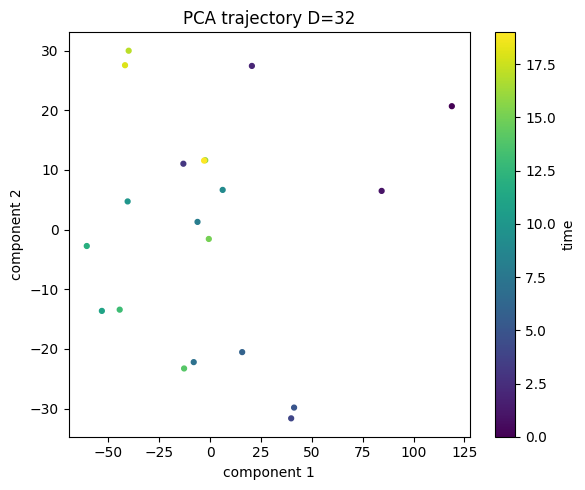

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


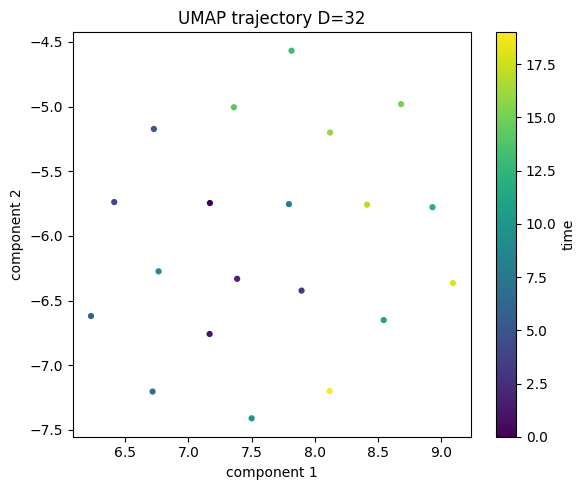

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


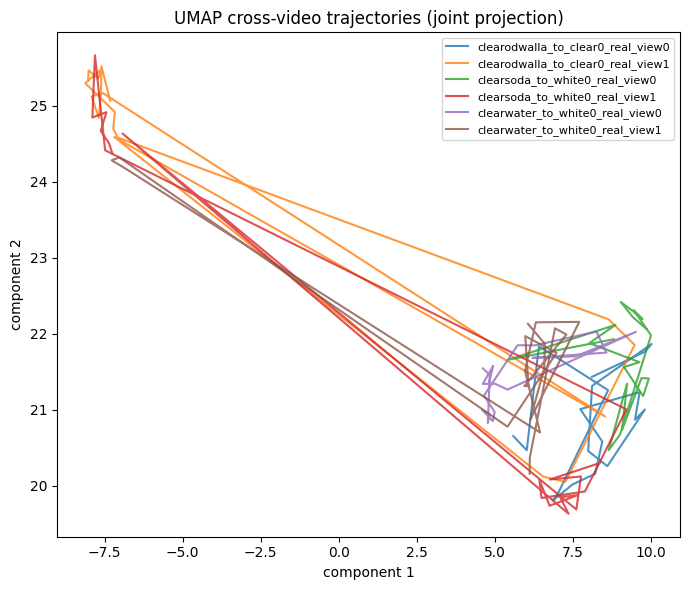

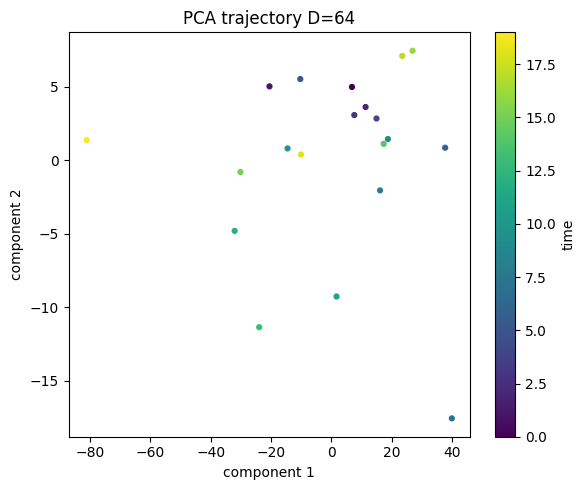

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


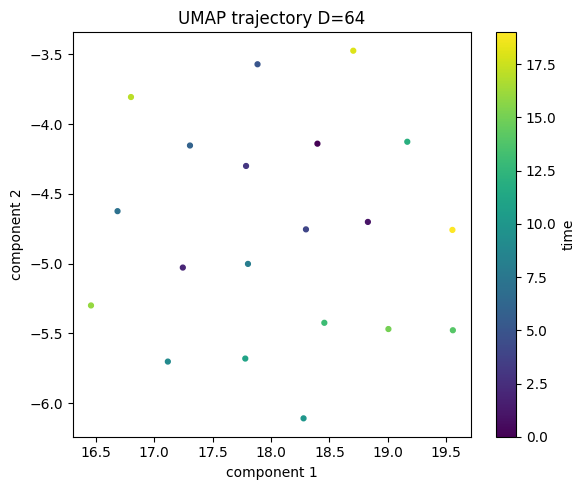

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


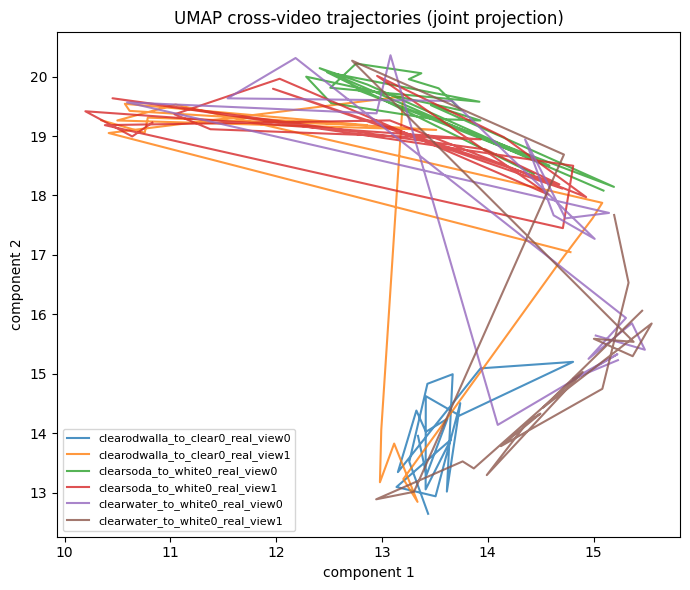

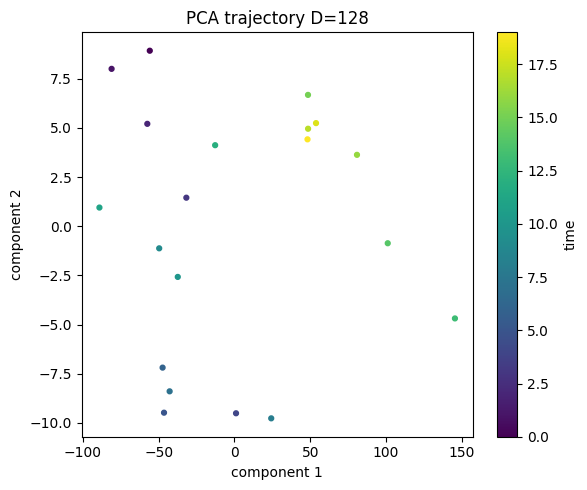

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


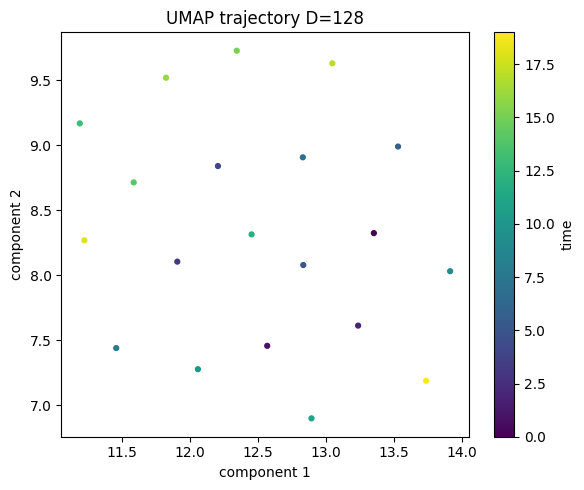

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


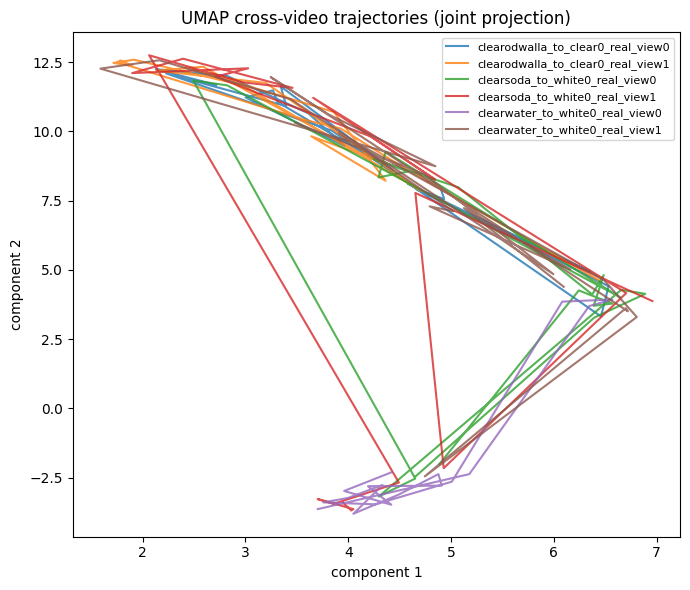

In [23]:
# Wrapper function to ease in running several plots.
def show_me(emb_bundle, dim):
    Z0 = emb_bundle["embeddings_list"][0]
    plot_single_trajectory(Z0, method="pca", title=f"PCA trajectory D={i}")
    plot_single_trajectory(Z0, method="umap", title=f"UMAP trajectory D={i}")
    plot_multiple_trajectories(emb_bundle["embeddings_list"], emb_bundle["names"], method="umap")

# Iterate through bundles and display.
for i in emb_bundles.keys():
    
    show_me(emb_bundles[i], i)



## 9. Temporal segmentation from embedding geometry

This section operationalizes the claim that the embedding has learned latent phase.

We use two complementary segmentation strategies:

### 9.1 Change-point detection

If the representation changes rapidly at phase transitions, then
$$
d_t = \|z_t - z_{t-1}\|
$$
should spike near boundaries. This is a **boundary-detection** approach — it finds *where* phase transitions occur without assigning cluster labels.

### 9.2 KMeans clustering in the native embedding space

If the embedding clusters by phase, KMeans should recover coarse phase labels. We use $k=6$ to match the six expected pouring phases (reach, grasp, lift, tilt, pour, retract). Experiment with different $k$ values to test sensitivity.

In [24]:
from sklearn.cluster import KMeans

def change_point_scores(Z):
    d = np.linalg.norm(Z[1:] - Z[:-1], axis=1)
    d = np.concatenate([[0.0], d])
    return d

def detect_boundaries(d, threshold_quantile=0.98, min_gap=10):
    thr = float(np.quantile(d, threshold_quantile))
    idx = np.where(d >= thr)[0].tolist()

    kept = []
    last = -10**9
    for i in idx:
        if i - last >= min_gap:
            kept.append(i)
            last = i
    return kept, thr

def cluster_kmeans(Z, k=6, seed=0):
    """KMeans with k=6 matching the six expected pouring phases."""
    return KMeans(n_clusters=k, random_state=seed, n_init="auto").fit_predict(Z)

In [25]:
def plot_segmentation(Z, labels=None, boundaries=None, title="Segmentation"):
    d = change_point_scores(Z)
    T = len(Z)

    plt.figure(figsize=(10, 3))
    plt.plot(np.arange(T), d)
    if boundaries is not None:
        for b in boundaries:
            plt.axvline(b, linestyle="--")
    plt.title(title + " — change-point score")
    plt.xlabel("frame index")
    plt.ylabel(r"$\|z_t-z_{t-1}\|$")
    plt.tight_layout()
    plt.show()

    if labels is not None:
        plt.figure(figsize=(10, 2))
        plt.plot(np.arange(T), labels, drawstyle="steps-mid")
        if boundaries is not None:
            for b in boundaries:
                plt.axvline(b, linestyle="--")
        plt.title(title + " — cluster labels over time")
        plt.xlabel("frame index")
        plt.ylabel("cluster")
        plt.tight_layout()
        plt.show()

In [26]:
# # Example usage:
# #
# Z = emb_bundle["embeddings_list"][0]
# d = change_point_scores(Z)
# boundaries, thr = detect_boundaries(d, threshold_quantile=0.98, min_gap=8)
# labels_km = cluster_kmeans(Z, k=6)

# plot_segmentation(Z, labels=labels_km, boundaries=boundaries, title="KMeans on native embeddings")

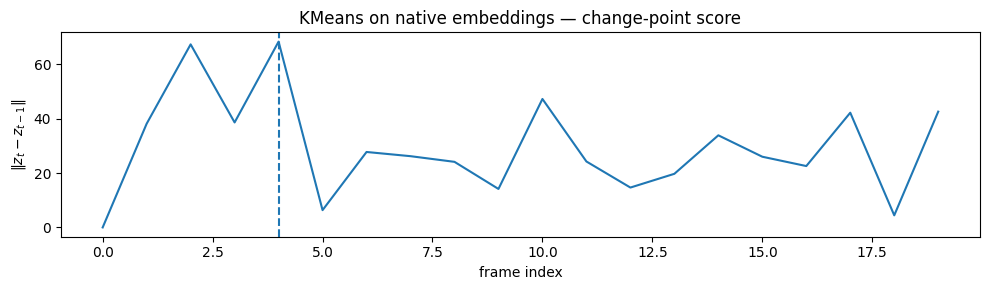

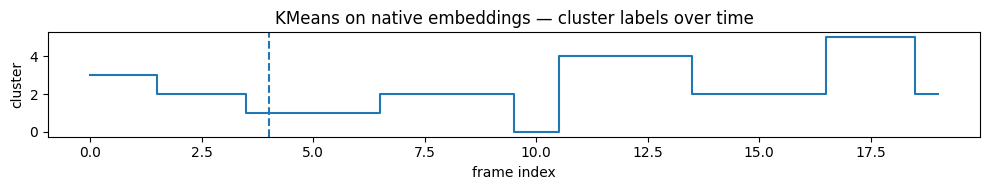

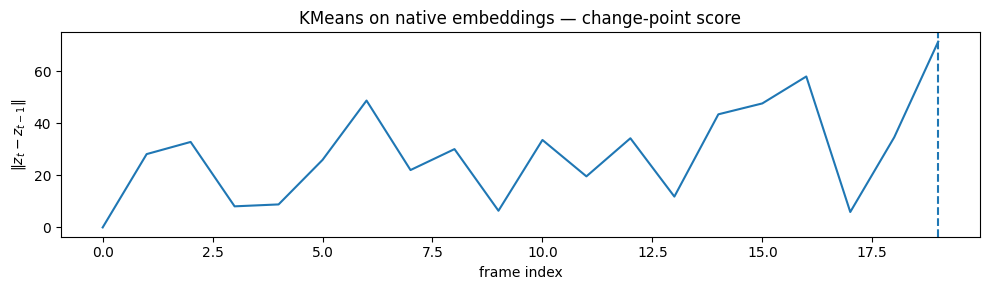

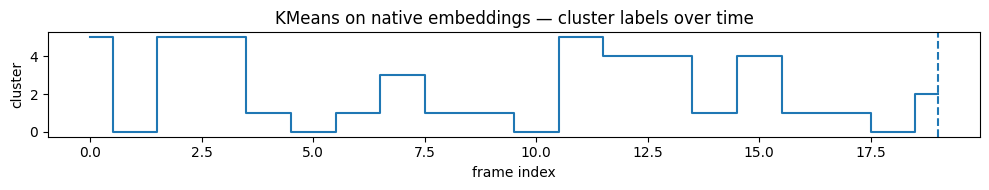

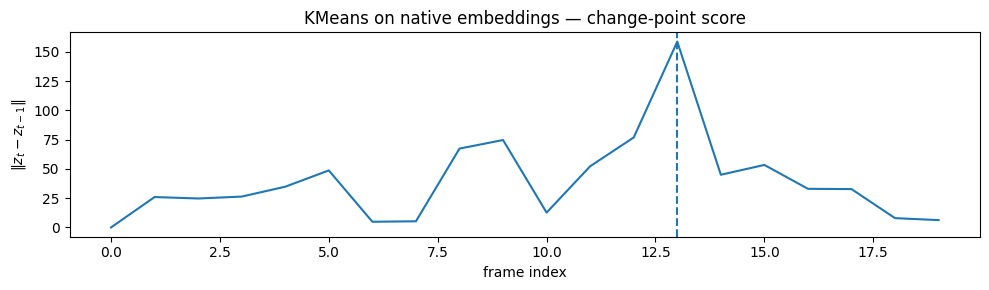

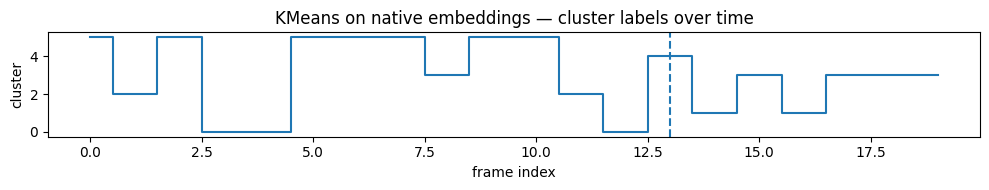

In [ ]:
for key in emb_bundles:
    
    # Get embed bundle.
    emb_bundle = emb_bundles[key]

    Z = emb_bundle["embeddings_list"][0]
    d = change_point_scores(Z)
    boundaries, thr = detect_boundaries(d, threshold_quantile=0.98, min_gap=8)
    labels_km = cluster_kmeans(Z, k=6)

    plot_segmentation(Z, labels=labels_km, boundaries=boundaries, title=f"KMeans on native embeddings  D={key}")


## 10. Embedding dimension sweep

The assignment asks you to compare:

- $D=32$
- $D=64$
- $D=128$

This matters because the embedding dimension controls the trade-off between:

- **compression**
- **expressiveness**
- **ease of clustering**
- **risk of overfitting appearance rather than phase**

In [53]:
def run_full_analysis_for_dimension(embed_dim, max_iters=5000, split="val",
                                    max_embs=0, num_videos_to_analyze=3):
    """Run the complete analysis pipeline for one embedding dimension.

    Analyzes up to num_videos_to_analyze videos (not just the first one)
    to ensure results are not artifacts of a single video.
    """
    cfg = make_run_config(embed_dim=embed_dim, max_iters=max_iters)
    bundle = extract_embeddings_for_run(cfg, split=split, max_embs=max_embs)

    print(f"\n===== Dimension {embed_dim} =====")
    print("Number of videos:", len(bundle["embeddings_list"]))
    print("Flat embedding matrix:", bundle["embeddings"].shape)

    if len(bundle["embeddings_list"]) == 0:
        print("No embeddings found.")
        return cfg, bundle

    n_analyze = min(num_videos_to_analyze, len(bundle["embeddings_list"]))

    for vid_idx in range(n_analyze):
        Z = bundle["embeddings_list"][vid_idx]
        vid_name = bundle["names"][vid_idx] if "names" in bundle else f"video_{vid_idx}"
        tag = f"D={embed_dim}, {vid_name}"

        plot_single_trajectory(Z, method="pca", title=f"PCA trajectory ({tag})")
        if HAS_UMAP:
            plot_single_trajectory(Z, method="umap", title=f"UMAP trajectory ({tag})")

        d = change_point_scores(Z)
        boundaries, thr = detect_boundaries(d, threshold_quantile=0.98, min_gap=8)
        labels_km = cluster_kmeans(Z, k=6)
        plot_segmentation(Z, labels=labels_km, boundaries=boundaries,
                          title=f"KMeans k=6 ({tag})")

    # Cross-video overlay (joint projection)
    if HAS_UMAP and len(bundle["embeddings_list"]) > 1:
        plot_multiple_trajectories(bundle["embeddings_list"], bundle.get("names"),
                                   method="umap")

    return cfg, bundle

# Example:
# cfg64, bundle64 = run_full_analysis_for_dimension(64, max_iters=5000)

split_dir: /workspaces/tcc/notebooks/self-supervised/data/pouring_processed/pouring/val
data loader: <torch.utils.data.dataloader.DataLoader object at 0x72df63349d50>
34
frames shape: torch.Size([2, 20, 3, 224, 224])
frame_labels shape: torch.Size([2, 20])
First few frame_labels: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
bundle: {'embeddings': array([[  0.6138468,  41.535923 , -11.457024 , ..., -34.131298 ,
         15.308263 , -29.905209 ],
       [ -0.3451595,  42.89798  , -12.27743  , ..., -35.041542 ,
         15.5759945, -30.303984 ],
       [  2.0367289,  21.895117 ,  -9.639488 , ..., -19.137005 ,
         12.966948 , -20.873688 ],
       ...,
       [  0.6742859,  29.302555 , -12.597637 , ..., -24.813932 ,
         12.637093 , -23.60323  ],
       [  5.4092836,  33.028564 ,  -5.553114 , ..., -27.110073 ,
         12.492165 , -24.949594 ],
       [  5.911847 ,  25.442608 ,  -3.36967

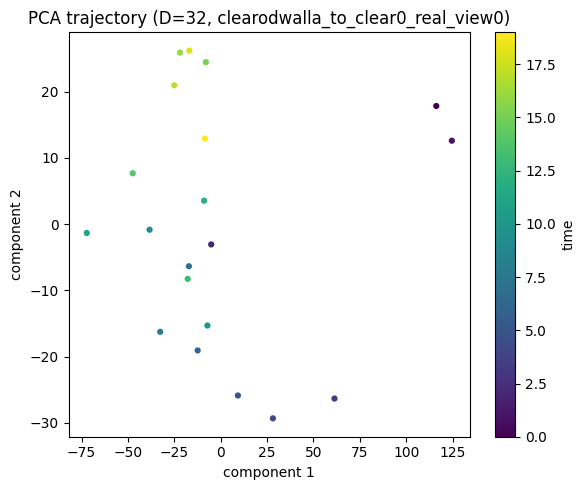

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


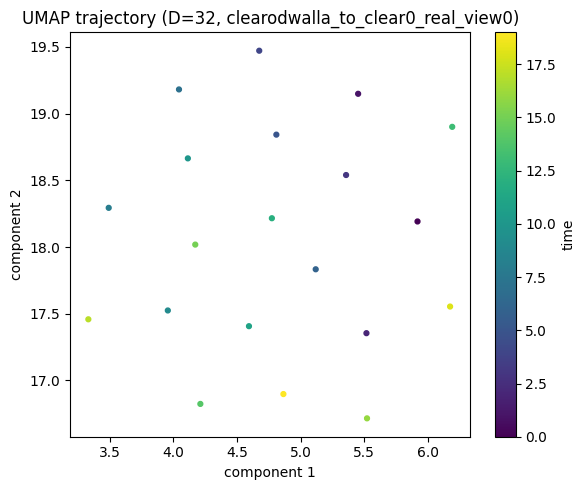

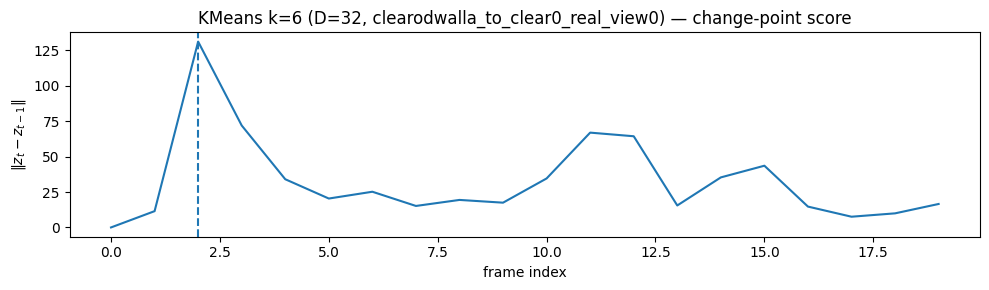

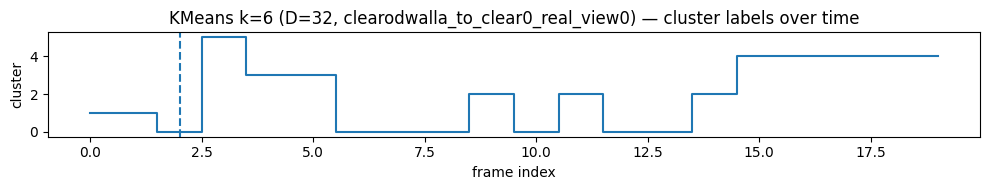

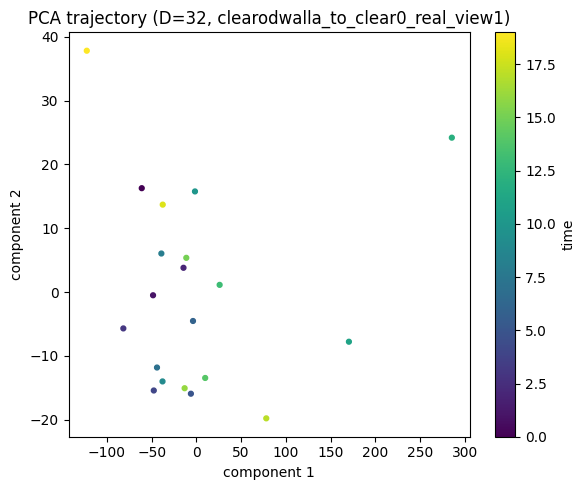

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


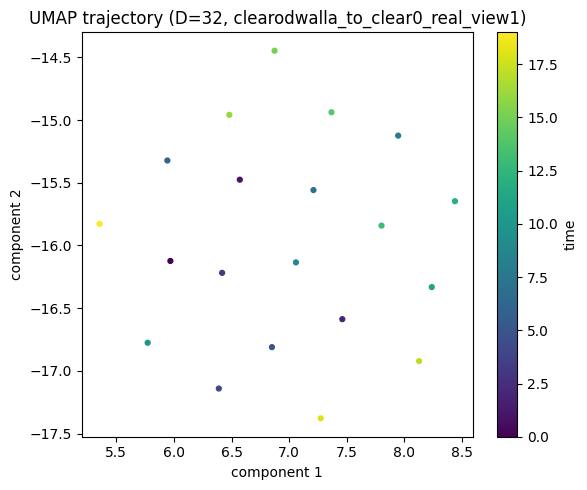

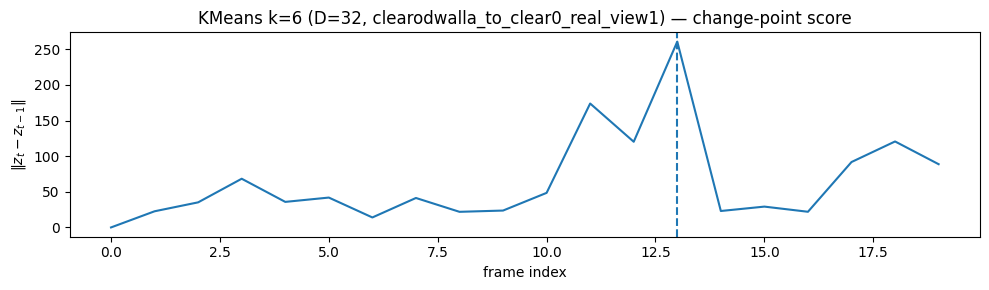

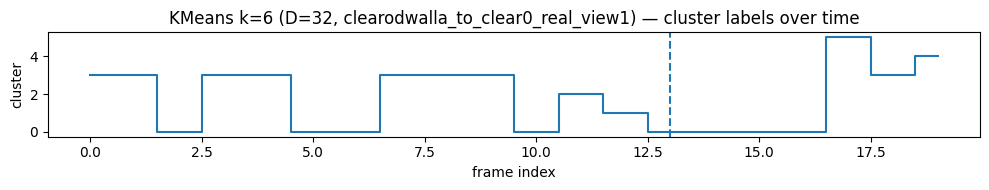

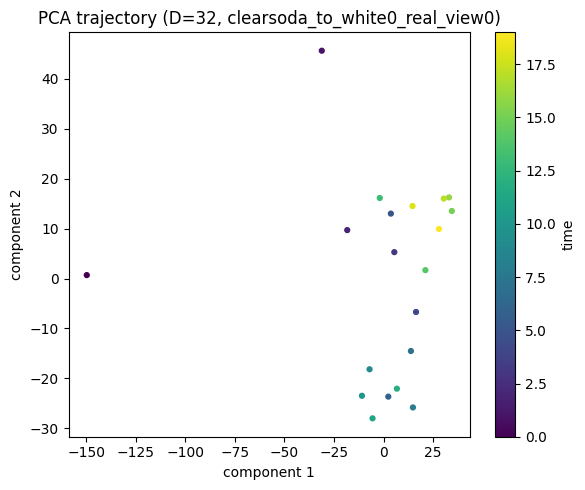

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


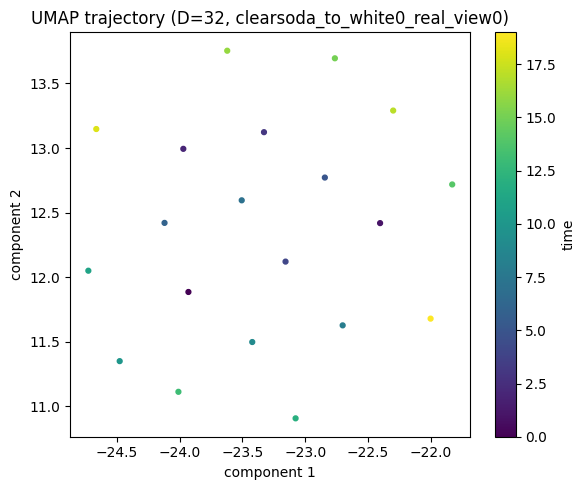

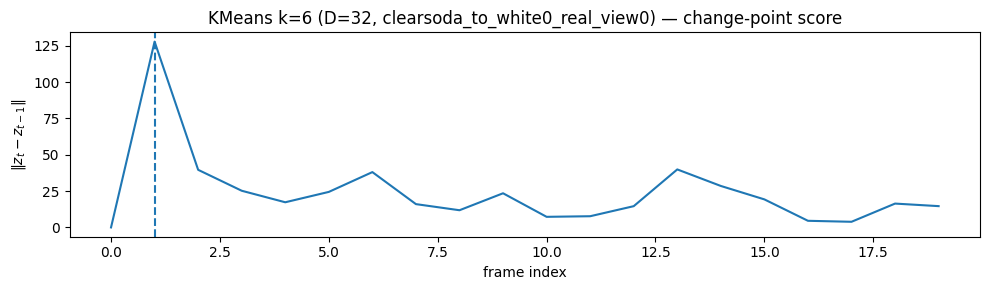

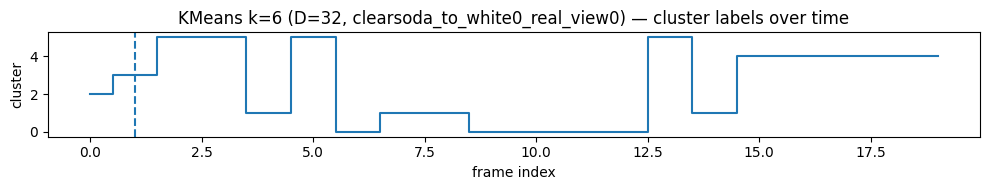

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


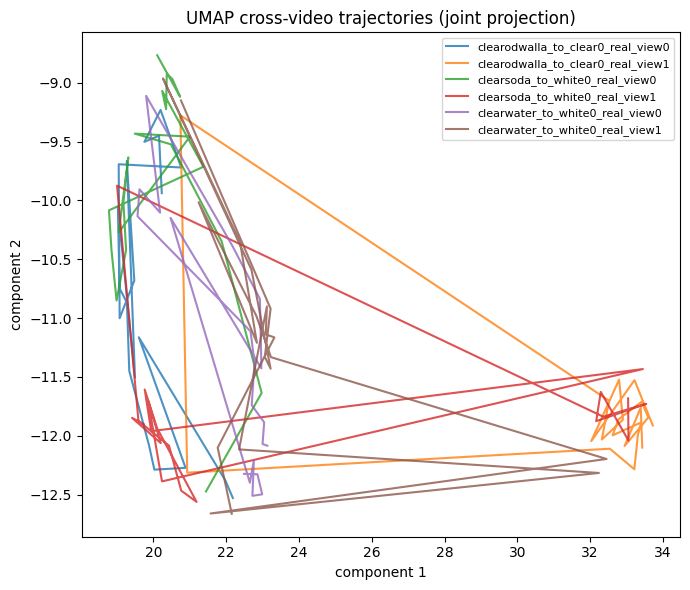

split_dir: /workspaces/tcc/notebooks/self-supervised/data/pouring_processed/pouring/val
data loader: <torch.utils.data.dataloader.DataLoader object at 0x72defdfc5450>
34
frames shape: torch.Size([2, 20, 3, 224, 224])
frame_labels shape: torch.Size([2, 20])
First few frame_labels: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
bundle: {'embeddings': array([[ 19.859707 ,  11.954648 ,   7.4474826, ..., -27.539413 ,
          5.9257936,   6.5823097],
       [ 18.461128 ,  12.202356 ,   6.9751067, ..., -26.752338 ,
          6.3260694,   6.651619 ],
       [ 20.149078 ,  11.971864 ,   8.449733 , ..., -26.753733 ,
          7.226386 ,   4.5023546],
       ...,
       [ 15.634214 ,   9.145414 ,   8.938214 , ..., -23.129644 ,
          2.3220537,   8.035391 ],
       [ 12.1815605,  10.717337 ,   3.1832323, ..., -20.917734 ,
          6.8422613,   5.1612186],
       [ 23.41715  ,  13.397862 ,  10.98770

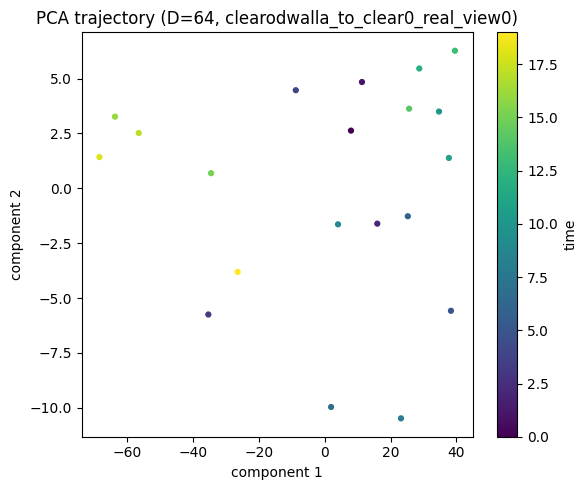

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


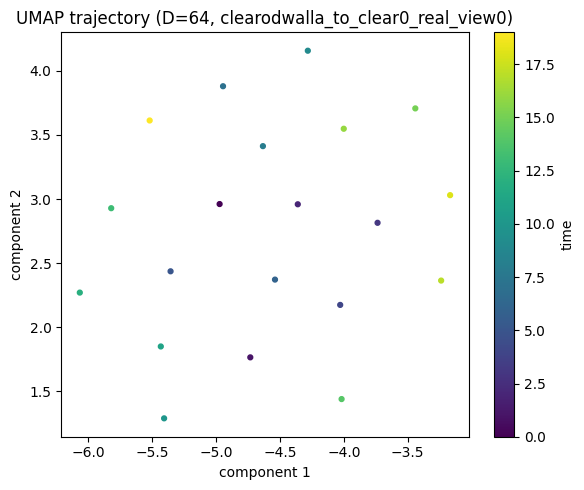

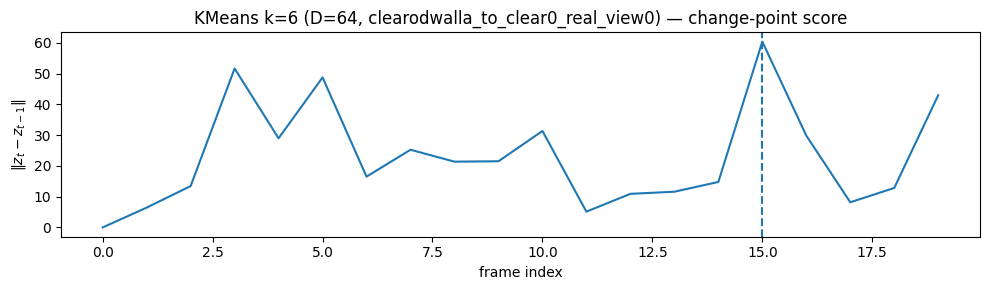

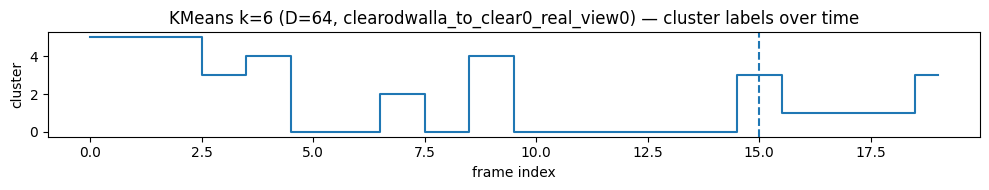

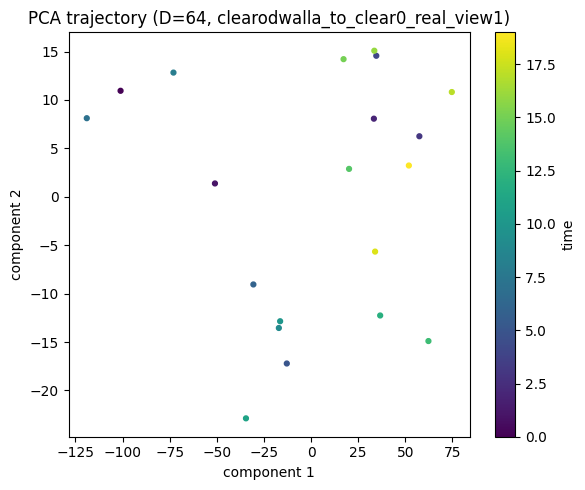

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


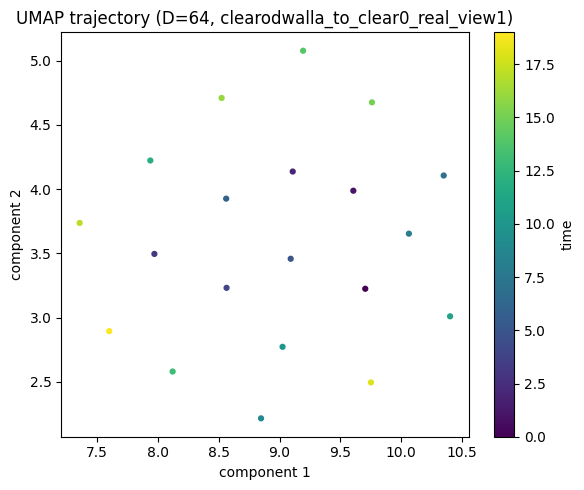

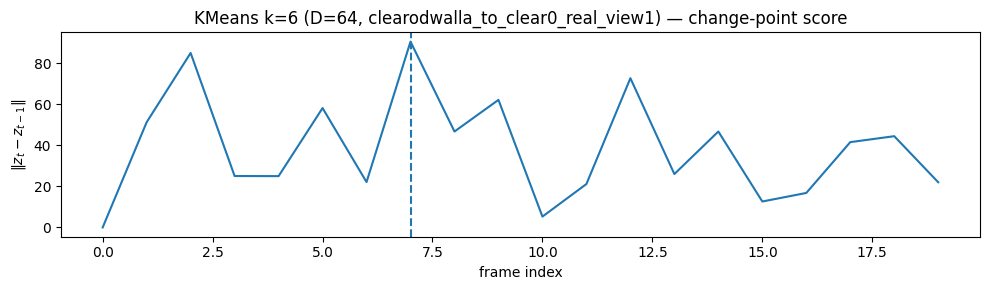

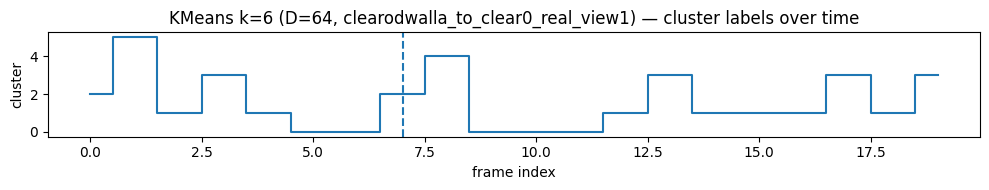

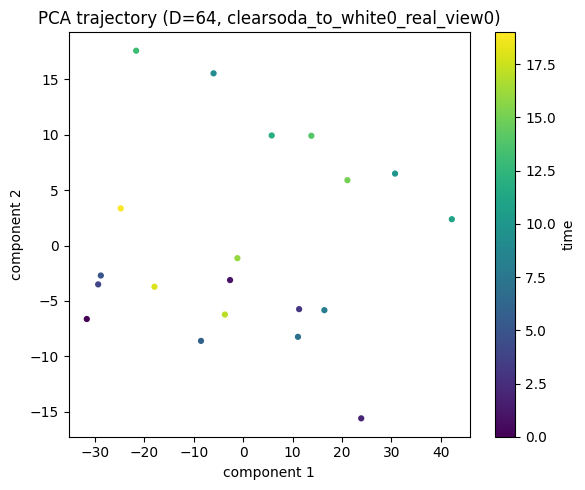

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


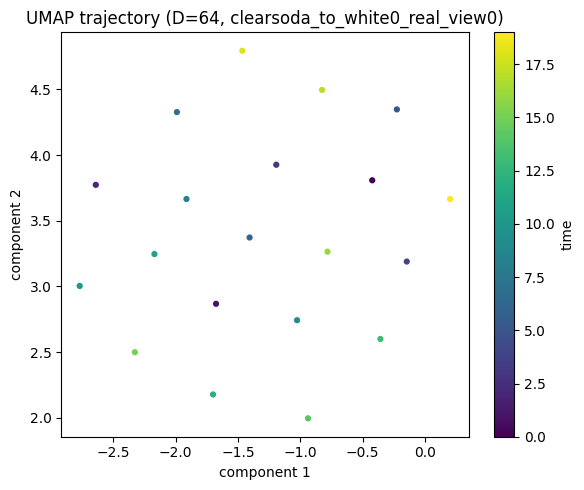

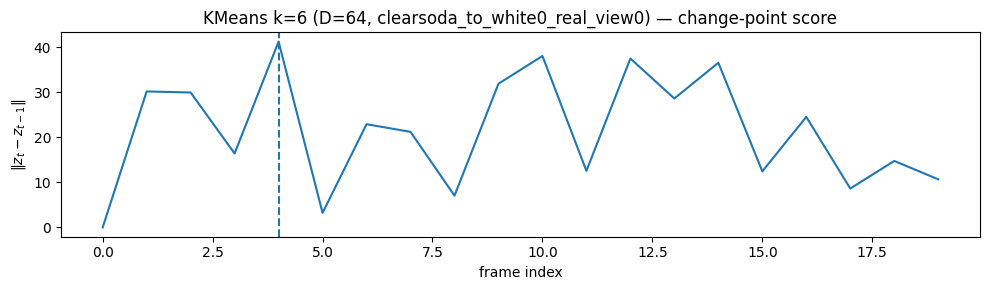

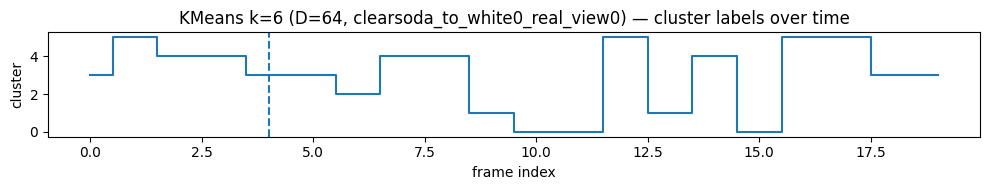

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


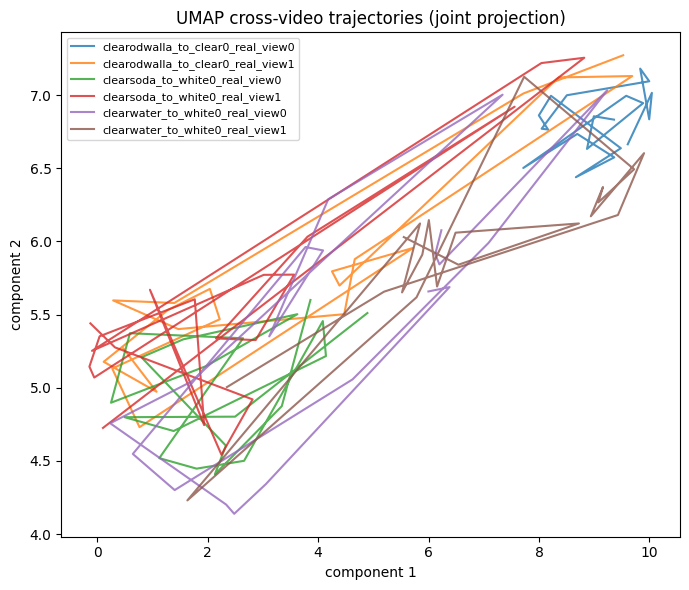

split_dir: /workspaces/tcc/notebooks/self-supervised/data/pouring_processed/pouring/val
data loader: <torch.utils.data.dataloader.DataLoader object at 0x72de92e3fa50>
34
frames shape: torch.Size([2, 20, 3, 224, 224])
frame_labels shape: torch.Size([2, 20])
First few frame_labels: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
bundle: {'embeddings': array([[ -1.8862537, -28.95557  ,  32.359844 , ...,  22.892134 ,
          8.268324 , -26.534462 ],
       [ -1.1370968, -29.40711  ,  32.170265 , ...,  24.04476  ,
          9.13529  , -26.298292 ],
       [ -1.759885 , -31.535086 ,  34.617405 , ...,  24.804049 ,
          8.073393 , -26.732586 ],
       ...,
       [ -2.3211787, -40.030014 ,  42.555965 , ...,  32.36743  ,
         11.900228 , -34.007557 ],
       [ -1.8505014, -48.50935  ,  51.20564  , ...,  38.284996 ,
         14.999164 , -40.144615 ],
       [ -1.4298104, -35.819386 ,  38.74016

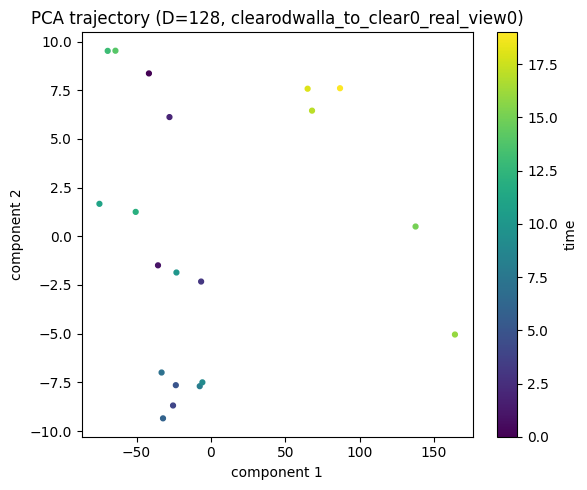

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


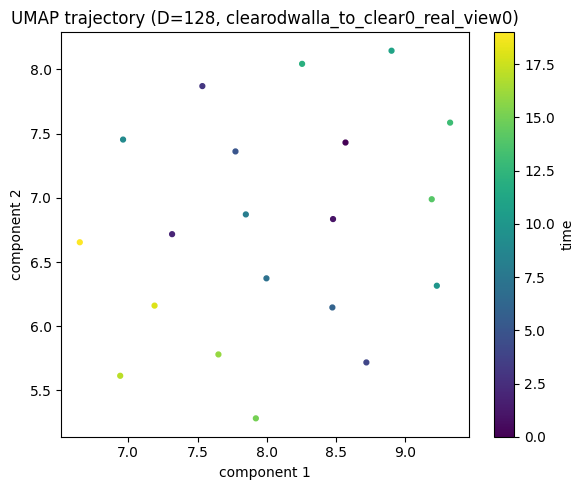

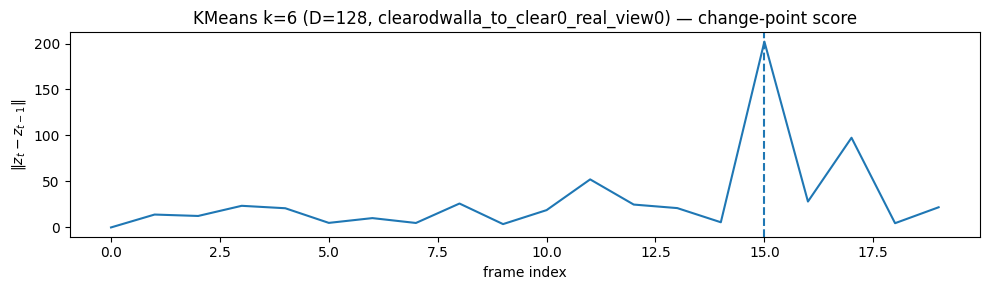

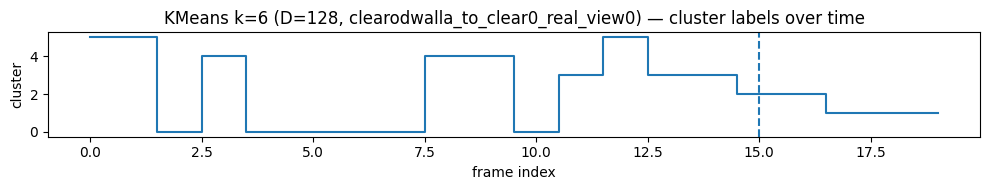

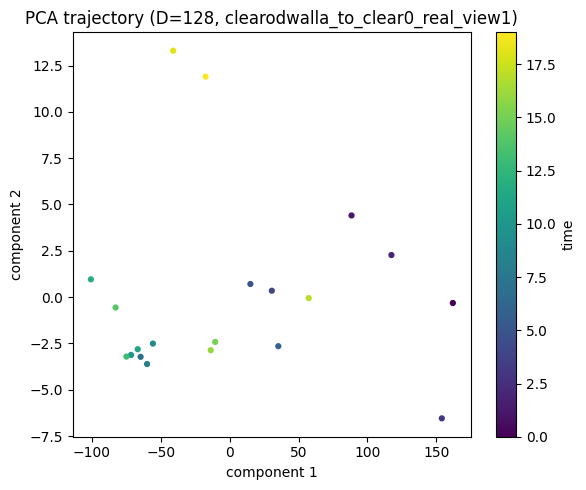

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


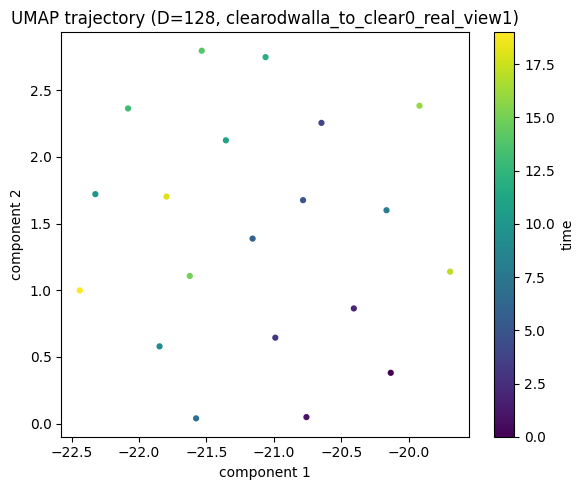

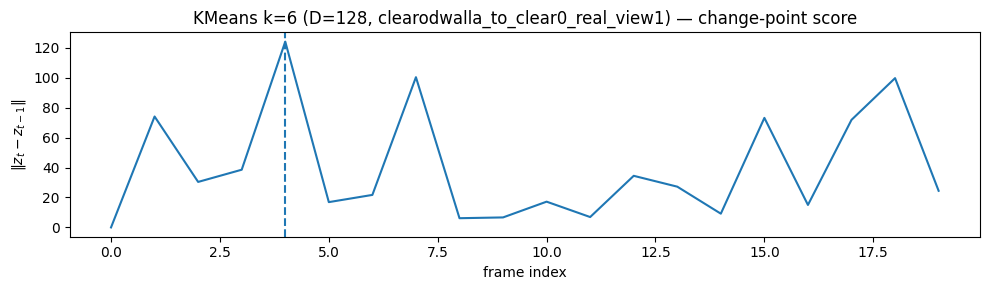

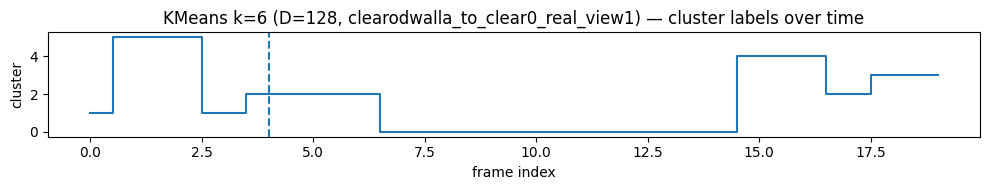

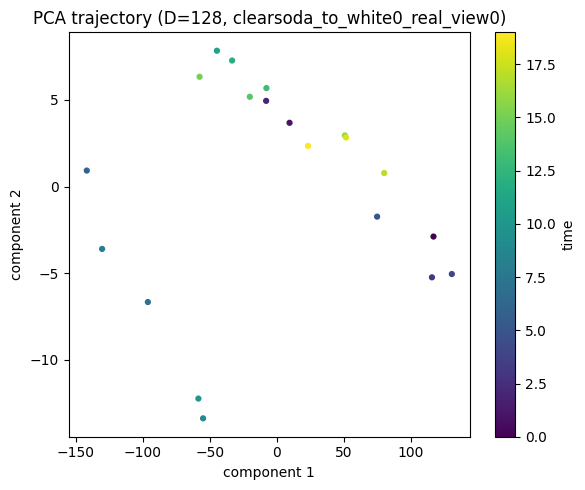

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


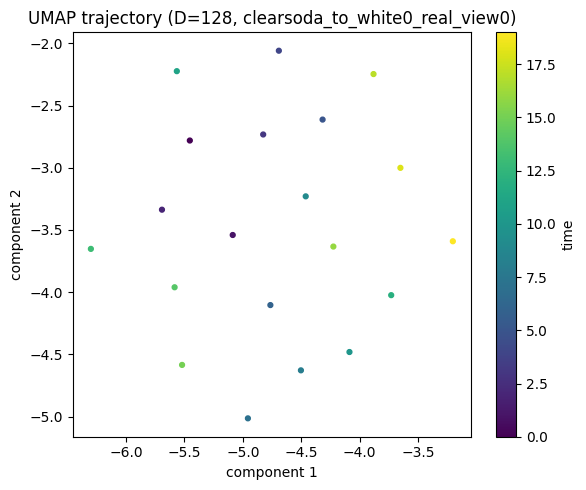

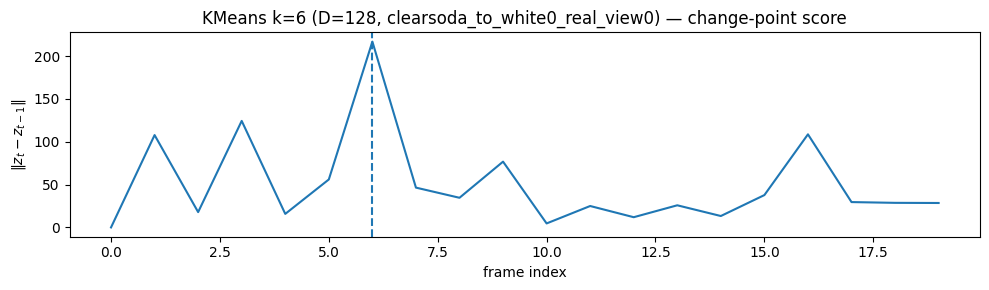

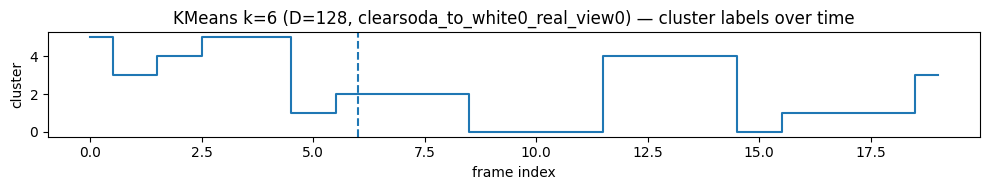

/workspaces/tcc/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


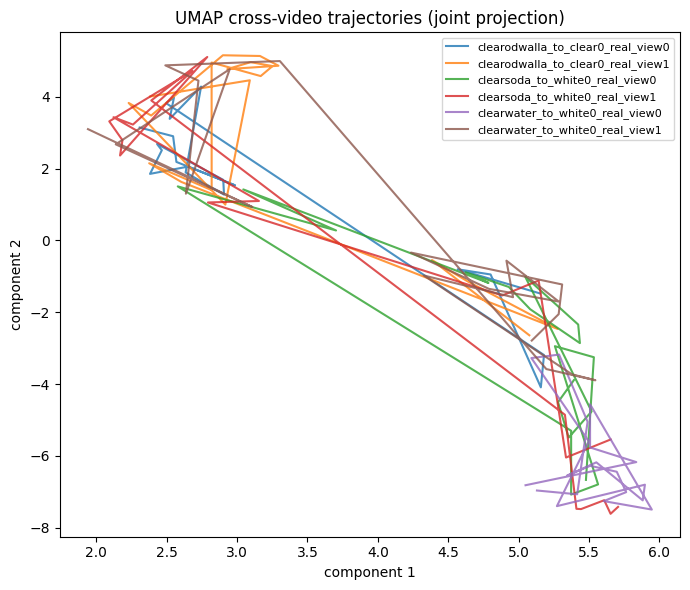

In [54]:
# Sweep through dimensions.
for d in EMBED_DIMS:
    cfg64, bundle64 = run_full_analysis_for_dimension(d, max_iters=5000)

## 11. Write-up questions

### Q1. TCN vs TCC
Explain, in your own words, the evolution from TCN to TCC. Include the role of the soft nearest-neighbor formulation in making cycle consistency differentiable.

### Q2. Does the learned representation encode phase?
Use your PCA and UMAP plots to justify a claim. Compare single-video trajectories with cross-video overlays.

### Q3. How well does segmentation recover phase structure?
Compare change-point detection and KMeans clustering. Do the detected boundaries align with qualitative phase transitions? Does varying $k$ change the story?

### Q4. What failure modes remain?
Examples:

- appearance variation dominating phase
- pauses causing over-segmentation
- self-similar frames across non-adjacent stages
- collapse of distinct phases into one cluster

## 12. Final checklist

Before submitting, verify that you have:

- trained at least one real TCC run on pouring
- extracted embeddings from a saved checkpoint
- produced PCA and UMAP trajectory plots for multiple videos
- produced a cross-video overlay using joint projection
- run both change-point detection and KMeans segmentation
- compared $D=32,64,128$
- written answers to all four questions (Q1–Q4) in inline markdown cells, with all supporting figures embedded in the notebook

That completes the assignment.